In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import os
warnings.filterwarnings('ignore')

In [2]:
## Global variables
HORIZON = 96
TEST_START_DATE = '2023-10-01'
VAL_START_DATE = '2023-09-01'
MODEL_PLOTS_DIR = '../outputs/model_plots/'
os.makedirs(MODEL_PLOTS_DIR, exist_ok=True)
MODELS = ['rf', 'xgb', 'lgb', 'cat']

In [5]:
TRAIN_FILES = [
    'DAM_April_2023.csv', 'DAM_May_2023.csv', 'DAM_June_2023.csv',
    'DAM_July_2023.csv', 'DAM_August_2023.csv', 'DAM_September_2023.csv'
]
TEST_FILE  = 'DAM_October_2023.csv'
DATA_DIR   = '../data/'

In [6]:
def load_dam(files, base_dir):
    frames = []
    for f in files:
        df = pd.read_csv(os.path.join(base_dir, f))
        print(f, df.shape)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

train_raw = load_dam(TRAIN_FILES, DATA_DIR)
test_raw  = load_dam([TEST_FILE], DATA_DIR)

DAM_April_2023.csv (2880, 5)
DAM_May_2023.csv (2976, 5)
DAM_June_2023.csv (2880, 5)
DAM_July_2023.csv (2976, 5)
DAM_August_2023.csv (2976, 5)
DAM_September_2023.csv (2880, 5)
DAM_October_2023.csv (2976, 5)


In [ ]:
train_raw.head() 

,Delivery Date,Time Period,Cleared Buy (MW),Cleared Sell (MW),Price (Rs./MWh)
0,01/04/2023,00:00-00:15,711.2,916.5,5487.60
1,01/04/2023,00:15-00:30,682.3,964.5,6043.92
2,01/04/2023,00:30-00:45,663.9,1026.0,6668.40
3,01/04/2023,00:45-01:00,666.3,1066.0,6668.23
4,01/04/2023,01:00-01:15,155.5,1031.5,6195.77


In [ ]:
# EDA in other file

### Data Preprocessing

In [7]:
def preprocess(df):
    df = df.copy()

    df.columns = ['date', 'time_period', 'buy_mw', 'sell_mw', 'price']

    df['start_time'] = df['time_period'].str.split('-').str[0].str.strip()
    df['datetime'] = pd.to_datetime(
            df['date'].str.strip() + ' ' + df['start_time'],
            format='%d/%m/%Y %H:%M'
        )
    df = df.drop(columns=['date', 'time_period', 'start_time'])

    # sort + deduplicate
    df = df.sort_values('datetime').drop_duplicates('datetime')
    df = df.set_index('datetime')
    
    # enforce frequency (important for rolling features)
    df = df.asfreq('15min')
    
    # handle missing
    # handling missing values - not needed but if needed -
    for col in ['price','buy_mw', 'sell_mw']:
        df[col] = df[col].interpolate()

    # Convert numeric columns
    for col in ['buy_mw', 'sell_mw', 'price']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.reset_index()
    
    return df

### Feature Engineering

In [8]:
def date_features(df):
    df = df.copy()

    df['dow'] = df['datetime'].dt.dayofweek 
    df['is_sunday'] = (df['dow'] == 6).astype(int)
    df['dow_sin']   = np.sin(2 * np.pi * df['dow'] / 7)
    df['dow_cos']   = np.cos(2 * np.pi * df['dow'] / 7)

    df['day'] = df['datetime'].dt.day
    df['is_month_start'] = (df['day'] <= 3).astype(int)
    df['is_month_end'] = (df['day'] >= 28).astype(int)

    df = df.drop(columns=['day'])

    return df

In [9]:
def hour_block_features(df):
    df = df.copy()
    df['hour'] = df['datetime'].dt.hour 
    df['is_peak_hours'] = df['hour'].between(19, 22).astype(int)
    df['is_valley_hour'] = df['hour'].between(8, 13).astype(int)

    df['date'] = df['datetime'].dt.date
    # yesterday's hourly average
    hourly_avg = (
        df.groupby(['date', 'hour'])['price']
        .mean()
        .groupby(level=1)
        .shift(1)
    )
    df['yday_same_hour_avg'] = pd.Series(list(zip(df['date'], df['hour']))).map(hourly_avg)
    

    df['block'] = df['hour'] * 4 + df['datetime'].dt.minute  // 15 
    df['sin_block'] = np.sin(2 * np.pi * df['block'] / 96)
    df['cos_block'] = np.cos(2 * np.pi * df['block'] / 96)

    df = df.drop(columns= ['date'])

    return df

In [10]:
def spike_features(df):
    df = df.copy()
    df['is_spike_prev'] = (df['price'].shift(96)>=10000).astype(int)
    df['spike_duration'] = df['is_spike_prev'].rolling(96).sum()
    df['spike_persistence'] = df['is_spike_prev'].rolling(96*3).mean()
    df['lag96_if_spike'] = df['price'].shift(96) * (df['price'].shift(96) == 10000)
    df['lag96_if_normal'] = df['price'].shift(96) * (df['price'].shift(96) < 10000)

    df['spike_magnitude'] = np.maximum(df['price'].shift(96) - 10000, 0)

     # plateau continuation signal
    df['plateau_flag'] = (
        df['price'].shift(96).rolling(4).std() < 50
        ).astype(int)

    return df

In [11]:
def voltality_features(df):
    df = df.copy()
    # daily amplitude feature - captures voltality of yesterday
    df['prevday_range'] = (
        df['price'].shift(96).rolling(96).max() -
        df['price'].shift(96).rolling(96).min()
    )
    # peak deviation feature
    df['prevday_peak_dev'] = (
        df['price'].shift(96).rolling(96).max() -
        df['price'].shift(96).rolling(96).mean()
    )
    df['price_prevday_dev'] = (
        df['price'].shift(96) -
        df['price'].shift(96).rolling(96*7).mean()
    )
    df['price_prevday_norm'] = (
        df['price'].shift(96) /
        df['price'].shift(96).rolling(96*7).mean()
    )
    df['vol_1d'] = df['price'].shift(96).rolling(96).std()
    df['vol_3d'] = df['price'].shift(96).rolling(96*3).std()
    df['vol_7d'] = df['price'].shift(96).rolling(96*7).std()
    df['vol_change'] = df['vol_1d'] - df['vol_3d']
    df['is_high_vol'] = (df['vol_1d'] > df['vol_7d']).astype(int) # more spikes likely

    df['is_high_vol'] = (df['vol_1d'] > df['vol_7d']).astype(int)
    df['prevday_peak'] = df['price'].shift(96).rolling(96).max()
    df['distance_to_peak'] = df['prevday_peak'] - df['price'].shift(96)

    return df

In [12]:
def lag_shape_features(df):
    df = df.copy()
    lags = [4*i for i in range(24)]
    lags.extend([96*i for i in range(1, 7)])
    print(lags)
    for i in lags:
        df[f'price_lag_{i+96}'] = df['price'].shift(i+96)

    df['delta_1d'] = df['price'].shift(96) - df['price'].shift(192)
    df['delta_7d'] = df['price'].shift(96) - df['price'].shift(672)
    
    df['roll_mean_96']  = df['price'].shift(96).rolling(96).mean()   # 24hr
    df['roll_mean_672'] = df['price'].shift(96).rolling(672).mean()  # 1wk
    df['price_trend_3h'] = df['price'].shift(96) - df['price'].shift(96+3*4)
    df['price_trend_6h'] = df['price'].shift(96) - df['price'].shift(96+6*4)

    df['prevday_slope'] = df['price'].shift(96) - df['price'].shift(96+4)
    df['prevday_acceleration'] = df['price'].shift(96) - 2*df['price'].shift(96+4) + df['price'].shift(96+8)
    
    return df


In [13]:
def buy_sell_features(df):
    df = df.copy()
    # Imbalance lag features
    df['diff_buy_sell'] = df['buy_mw']-df['sell_mw']
    df['imbalance_lag_96'] = df['diff_buy_sell'].shift(96)
    df['ratio_lag_96'] = np.log1p(df['buy_mw'].shift(96) / (df['sell_mw'].shift(96) + 1))
    
    # Drop the original buy/sell columns as they are "future" data during prediction
    df = df.drop(columns=['buy_mw', 'sell_mw', 'diff_buy_sell'])
    return df

In [14]:
def midnight_lag_features(df):
    """
    For any row on 2023-10-03 (any time):
    Take midnight → 2023-10-03 00:00
    Then:
    lag_1 → 2023-10-02 23:45
    lag_4 → 2023-10-02 23:00
    lag_8 → 2023-10-02 22:00
    And this should be same for all rows of that day
    """
    df = df.copy()
    df['midnight'] = df['datetime'].dt.floor('D')
    for i in range(96):
        df[f'price_prevday_{i}'] = (
            df['midnight'] - pd.Timedelta(minutes=15*(i+1))
        ).map(df.set_index('datetime')['price'])


    df = df.drop(columns=['midnight'])

    return df

In [15]:
def feature_engg(df):
    df = df.copy()
    df = date_features(df)
    print("--- date features created ---")
    df = hour_block_features(df)
    print("--- hour_block_features created ---")
    df = spike_features(df)
    print("--- hour_block_features created ---")
    df = voltality_features(df)
    print("--- voltality_features created ---")
    df = lag_shape_features(df)
    print("--- lag_shape_features created ---")
    df = buy_sell_features(df)
    print("--- buy_sell_features created ---")
    df = midnight_lag_features(df)
    print("--- midnight lag features created ---")
    nan_min_time = df.loc[df.isna().any(axis=1), 'datetime'].min()
    nan_max_time = df.loc[df.isna().any(axis=1), 'datetime'].max()
    print(f'Min nan date time: {nan_min_time}')
    print(f'Max nan date time: {nan_max_time}')
    df = df.dropna().reset_index(drop=True)
    return df

In [16]:
train_data = preprocess(train_raw)
test_data  = preprocess(test_raw)

In [17]:
full_data = pd.concat([train_data, test_data], ignore_index=True)
full_data = full_data.sort_values('datetime').reset_index(drop=True)

In [18]:
full_data = feature_engg(full_data)

--- date features created ---
--- hour_block_features created ---
--- hour_block_features created ---
--- voltality_features created ---
[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 76, 80, 84, 88, 92, 96, 192, 288, 384, 480, 576]
--- lag_shape_features created ---
--- buy_sell_features created ---
--- midnight lag features created ---
Min nan date time: 2023-04-01 00:00:00
Max nan date time: 2023-04-08 23:30:00


In [19]:
full_data.shape

(19777, 169)

### Dataset preparation

In [20]:
feature_cols = [c for c in full_data.columns if c not in ['datetime', 'price']]
target_col = 'price'

In [22]:
train_df = full_data[full_data['datetime'] < VAL_START_DATE]
val_df = full_data[(full_data['datetime'] >= VAL_START_DATE)&(full_data['datetime'] < TEST_START_DATE)]
test_df  = full_data[full_data['datetime'] >= TEST_START_DATE]
train_val_df = full_data[full_data['datetime'] < TEST_START_DATE]

In [23]:
print(train_df.shape, val_df.shape, test_df.shape, train_val_df.shape)

(13921, 169) (2880, 169) (2976, 169) (16801, 169)


In [24]:
print(f'train data : {train_df.datetime.min()} -> {train_df.datetime.max()}')
print(f'val data   : {val_df.datetime.min()} -> {val_df.datetime.max()}')
print(f'test data  : {test_df.datetime.min()} -> {test_df.datetime.max()}')

train data : 2023-04-08 23:45:00 -> 2023-08-31 23:45:00
val data   : 2023-09-01 00:00:00 -> 2023-09-30 23:45:00
test data  : 2023-10-01 00:00:00 -> 2023-10-31 23:45:00


In [21]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')


### Hyperparameter tuning

In [27]:
def tune_model(model_class, param_grid, X_train, y_train, X_val, y_val, fixed_params=None):
    best_params = None
    best_score = float('inf')

    if fixed_params is None:
        fixed_params = {}

    for params in param_grid:
        # Merge grid params with fixed params
        all_params = {**params, **fixed_params}

        model = model_class(**all_params)
        model.fit(X_train, y_train)

        pred = model.predict(X_val)
        score = mean_absolute_error(y_val, pred)

        print("Params:", params, "| MAE:", round(score, 2))

        if score < best_score:
            best_score = score
            best_params = all_params

    return best_params, best_score


In [28]:
class_models = {
    'rf' : RandomForestRegressor,
    'xgb': XGBRegressor,
    'lgb': LGBMRegressor,
    'cat': CatBoostRegressor
}

In [29]:
grids = {
    'rf': [
        {'n_estimators': 200, 'max_depth': 10},
        {'n_estimators': 300, 'max_depth': 12},
        {'n_estimators': 500, 'max_depth': 15},
    ],
    'xgb': [
        {'n_estimators':300, 'max_depth':6, 'learning_rate':0.05},
        {'n_estimators':500, 'max_depth':8, 'learning_rate':0.03},
        {'n_estimators':700, 'max_depth':10, 'learning_rate':0.02},
    ],
    'lgb': [
        {'n_estimators':800, 'learning_rate':0.03, 'num_leaves':63, 'max_depth':-1, 'min_child_samples':50, 'subsample':0.8, 'colsample_bytree':0.8},
        {'n_estimators':1200, 'learning_rate':0.02, 'num_leaves':63, 'max_depth':-1, 'min_child_samples':50, 'subsample':0.8, 'colsample_bytree':0.8},
        {'n_estimators':1400, 'learning_rate':0.01, 'num_leaves':127, 'max_depth':10, 'min_child_samples':100, 'subsample':0.7, 'colsample_bytree':0.7}
    ],
    'cat': [
        {'iterations':500, 'depth':6, 'learning_rate':0.05},
        {'iterations':800, 'depth':8, 'learning_rate':0.03},
        {'iterations':1000, 'depth':10, 'learning_rate':0.02},
        {}
    ]
}

In [30]:
fixed_params = {
    'rf' : {'n_jobs': -1, 'random_state': 42},
    'xgb': {'subsample': 0.6, 'colsample_bytree': 0.7, 'random_state': 42, 'n_jobs' : -1},
    'lgb': {'n_jobs': -1, 'random_state': 42, 'verbose': -2},
    'cat': {'random_state': 42, 'logging_level':'Silent'}
}

In [31]:
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

In [32]:
best_params = {}
best_val_score = {}

In [33]:
for model_name in MODELS:
    print(f"-----{model_name}-----")
    best_params[model_name], best_val_score[model_name] = tune_model(
        class_models[model_name],
        grids[model_name],
        X_train, y_train,
        X_val, y_val,
        fixed_params[model_name]
)


-----rf-----
Params: {'n_estimators': 200, 'max_depth': 10} | MAE: 1166.61
Params: {'n_estimators': 300, 'max_depth': 12} | MAE: 1178.17
Params: {'n_estimators': 500, 'max_depth': 15} | MAE: 1196.02
-----xgb-----
Params: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05} | MAE: 1244.57
Params: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.03} | MAE: 1241.66
Params: {'n_estimators': 700, 'max_depth': 10, 'learning_rate': 0.02} | MAE: 1247.94
-----lgb-----
Params: {'n_estimators': 800, 'learning_rate': 0.03, 'num_leaves': 63, 'max_depth': -1, 'min_child_samples': 50, 'subsample': 0.8, 'colsample_bytree': 0.8} | MAE: 1242.39
Params: {'n_estimators': 1200, 'learning_rate': 0.02, 'num_leaves': 63, 'max_depth': -1, 'min_child_samples': 50, 'subsample': 0.8, 'colsample_bytree': 0.8} | MAE: 1247.95
Params: {'n_estimators': 1400, 'learning_rate': 0.01, 'num_leaves': 127, 'max_depth': 10, 'min_child_samples': 100, 'subsample': 0.7, 'colsample_bytree': 0.7} | MAE: 1298.43
---

In [34]:
print(best_val_score)

{'rf': 1166.6116789515177, 'xgb': 1241.657215128581, 'lgb': 1242.3925243748322, 'cat': 1209.2496917667331}


In [35]:
print(best_params)


{'rf': {'n_estimators': 200, 'max_depth': 10, 'n_jobs': -1, 'random_state': 42}, 'xgb': {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.03, 'subsample': 0.6, 'colsample_bytree': 0.7, 'random_state': 42, 'n_jobs': -1}, 'lgb': {'n_estimators': 800, 'learning_rate': 0.03, 'num_leaves': 63, 'max_depth': -1, 'min_child_samples': 50, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_jobs': -1, 'random_state': 42, 'verbose': -2}, 'cat': {'iterations': 1000, 'depth': 10, 'learning_rate': 0.02, 'random_state': 42, 'logging_level': 'Silent'}}


### Evaluate

In [36]:
def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask])) / (y_true[mask]+1e-6)) * 100
    # print(f'[{label}]  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


### Visualizations

##### Feature importance

In [37]:
def get_importance(model, feature_names):
    """Extract feature importance for different model types"""
    
    if hasattr(model, "feature_importances_"):
        return model.feature_importances_
    
    elif hasattr(model, "get_booster"):  # XGBoost
        booster = model.get_booster()
        score = booster.get_score(importance_type='gain')
        
        importances = np.zeros(len(feature_names))
        for i in range(len(feature_names)):
            importances[i] = score.get(f"f{i}", 0.0)
        return importances
    
    elif hasattr(model, "get_feature_importance"):  # CatBoost
        return model.get_feature_importance()
    
    else:
        raise ValueError("Unsupported model")


def plot_all_feature_importance(models_dict, feature_names, top_n=20):
    """
    models_dict = {
        'RandomForest': rf_model,
        'XGBoost': xgb_model,
        'LightGBM': lgb_model,
        'CatBoost': cat_model
    }
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for ax, (name, model) in zip(axes, models_dict.items()):
        
        importances = get_importance(model, feature_names)
        
        idx = np.argsort(importances)[::-1][:top_n]
        
        top_features = [feature_names[i] for i in idx]
        top_importances = importances[idx]
        
        ax.barh(range(len(top_features)), top_importances[::-1])
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features[::-1])
        ax.set_title(name)
        ax.set_xlabel("Importance")
    
    plt.tight_layout()
    plt.show()

##### Actual vs predicted price

In [38]:
def plot_actual_vs_pred_scatter(df):
    plt.figure(figsize=(6,6))
    sns.scatterplot(
        data=df,
        x='price',
        y='y_pred',
        hue='model',
        alpha=0.4
    )
    # perfect prediction line
    min_val = df[['price','y_pred']].min().min()
    max_val = df[['price','y_pred']].max().max()
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

    plt.title("Actual vs Predicted")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

In [39]:
def plot_timeseries(df, start=None, end=None):
    temp = df.copy()

    if start:
        temp = temp[temp['datetime'] >= start]
    if end:
        temp = temp[temp['datetime'] <= end]

    plt.figure(figsize=(12,5))

    # Actual (single line)
    actual = temp.drop_duplicates('datetime')
    plt.plot(actual['datetime'], actual['price'], label='Actual')

    # Predictions
    sns.lineplot(
        data=temp,
        x='datetime',
        y='y_pred',
        hue='model',
        linestyle='--'
    )

    plt.title("Time Series: Actual vs Predictions")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

##### Daily Curves

In [40]:
def plot_daily_curves(df_plot, n_days=5, seed=42):

    df = df_plot.copy()
    df['date'] = df['datetime'].dt.date
    df['day'] = df['datetime'].dt.day
    df['block'] = df['datetime'].dt.hour * 4 + df['datetime'].dt.minute // 15

    np.random.seed(seed)
    unique_days = df['date'].unique()
    selected_days = np.random.choice(unique_days, size=n_days, replace=False)

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    axes = axes.flatten()

    # ---- Plot 5 random days ----
    for i, d in enumerate(selected_days):
        temp = df[df['date'] == d].sort_values('block')
        ax = axes[i]

        # Actual (only one line needed)
        sns.lineplot( x='block', y='price',
            data=temp.drop_duplicates('datetime'),
            ax=ax, label='Actual'
        )

        # Predictions (by model)
        sns.lineplot( x='block', y='y_pred', hue='model',
            data=temp,
            ax=ax, linestyle='--'
        )

        ax.set_title(f"{d}")
        ax.legend().remove()

    # ---- Daily average plot ----
    avg_actual = df.drop_duplicates('datetime') \
                    .groupby('day')['price'] \
                    .mean().reset_index()

    avg_pred = df.groupby(['day', 'model'])['y_pred'].mean().reset_index()

    ax = axes[-1]

    # Actual
    sns.lineplot(x='day', y='price', data=avg_actual, ax=ax, label='Actual')

    # Predictions
    sns.lineplot(
        x='day', y='y_pred',
        hue='model',
        data=avg_pred,
        ax=ax,
        linestyle='--'
    )

    ax.set_title("Daily average price curve")

    # Global legend
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')

    plt.tight_layout()
    plt.show()

##### Error Distribution

In [41]:
def plot_error_distribution(df):
    df = df.copy()
    df['error'] = df['y_pred'] - df['price']

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df,
        x='error',
        hue='model',
        bins=60,
        kde=True,
        stat='density',
        common_norm=False,
        alpha=0.4
    )

    plt.title("Error Distribution")
    plt.xlabel("Error")
    plt.show()



##### Voltality plot

In [42]:
def plot_volatility(df, window=96):
    df = df.copy().sort_values('datetime')

    # actual volatility
    actual = df.drop_duplicates('datetime').copy()
    actual['vol'] = actual['price'].rolling(window).std()

    plt.figure(figsize=(12,5))
    plt.plot(actual['datetime'], actual['vol'], label='Actual')

    # model volatility
    for m in df['model'].unique():
        temp = df[df['model'] == m].copy()
        temp['vol'] = temp['y_pred'].rolling(window).std()
        plt.plot(temp['datetime'], temp['vol'], label=m.upper())

    plt.title("Volatility (Rolling Std)")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

### Training and inference

In [44]:
def train_predict(train_data, test_data, feature_cols, target_col, model_store, best_params = {}, model_type = 'rf'):
    train_df = train_data.copy()
    test_df = test_data.copy()

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    
    model = class_models[model_type](**best_params[model_type])
    model.fit(X_train, y_train)
    model_store[model_type] = model 
    print("Training done")

    X_test = test_df[feature_cols]
    y_pred = model.predict(X_test)
    print("Prediction done")

    test_df['y_pred'] = y_pred
    test_df['y_pred'] = test_df['y_pred'].clip(upper=10000)
    test_df['model'] = model_type

    return test_df[['datetime', target_col, 'y_pred', 'model']]


##### Naive predictions

In [45]:
def plot_daily_average(df):
    df = df.copy()
    df['date'] = df['datetime'].dt.date

    actual = df.drop_duplicates('datetime') \
               .groupby('date')['price'] \
               .mean().reset_index()

    pred = df.groupby(['date'])['price_lag_96'] \
             .mean().reset_index()

    plt.figure(figsize=(10,5))

    sns.lineplot(x='date', y='price', data=actual, label='Actual')

    sns.lineplot(
        x='date', y='price_lag_96',
        data=pred,
        linestyle='--'
    )

    plt.title("Daily Average Trend")
    plt.xticks(rotation=45)
    plt.show()

In [46]:
evaluate(val_df['price'].values, val_df['price_lag_96'].values, "naive_val")

{'MAE': 1001.1927777777778,
 'RMSE': np.float64(1611.131784801599),
 'MAPE': np.float64(20.16941530031827)}

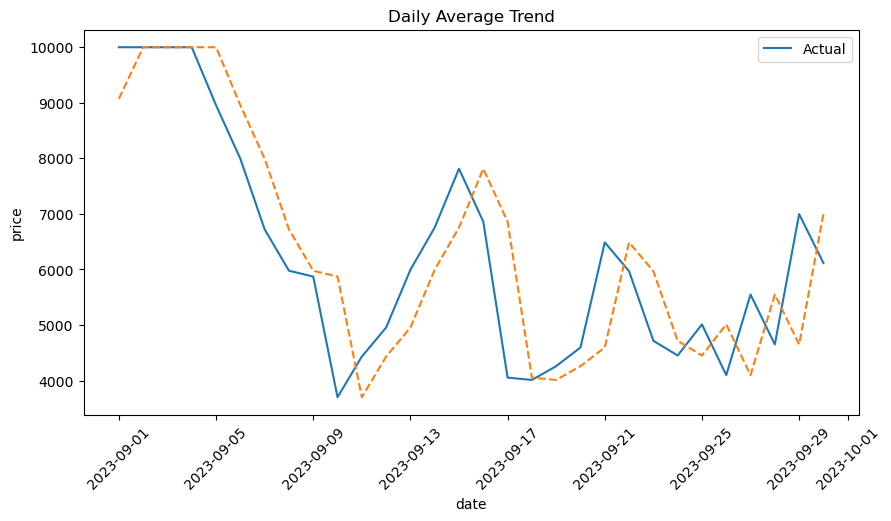

In [47]:
plot_daily_average(val_df)

#### Validation dataset

In [48]:
results_val = []
model_dict_val = {}
for m in MODELS:
    print(f'======{m}======')
    df = train_predict(train_df, val_df, feature_cols, target_col, model_dict_val, best_params, m)
    results_val.append(df)
results_val = pd.concat(results_val, ignore_index=True)

======rf======
Training done
Prediction done
======xgb======
Training done
Prediction done
======lgb======
Training done
Prediction done
======cat======
Training done
Prediction done


In [49]:
# evaluation
metrics_val = results_val.groupby('model').apply(
                lambda x: evaluate(x['price'].values, x['y_pred'].values)
            )
metrics_val = metrics_val.apply(pd.Series).reset_index().rename(columns={'index': 'model'})
metrics_val

,model,MAE,RMSE,MAPE
0,cat,1209.182707,1579.958899,23.365378
1,lgb,1235.988971,1693.504653,24.694784
2,rf,1166.611679,1614.635659,23.188841
3,xgb,1239.981658,1639.118959,24.473127


In [50]:
evaluate(val_df['price'].values, val_df['price_lag_96'].values, "naive_val")

{'MAE': 1001.1927777777778,
 'RMSE': np.float64(1611.131784801599),
 'MAPE': np.float64(20.16941530031827)}

##### Val visualization

In [51]:
df_plot_val = results_val.copy()

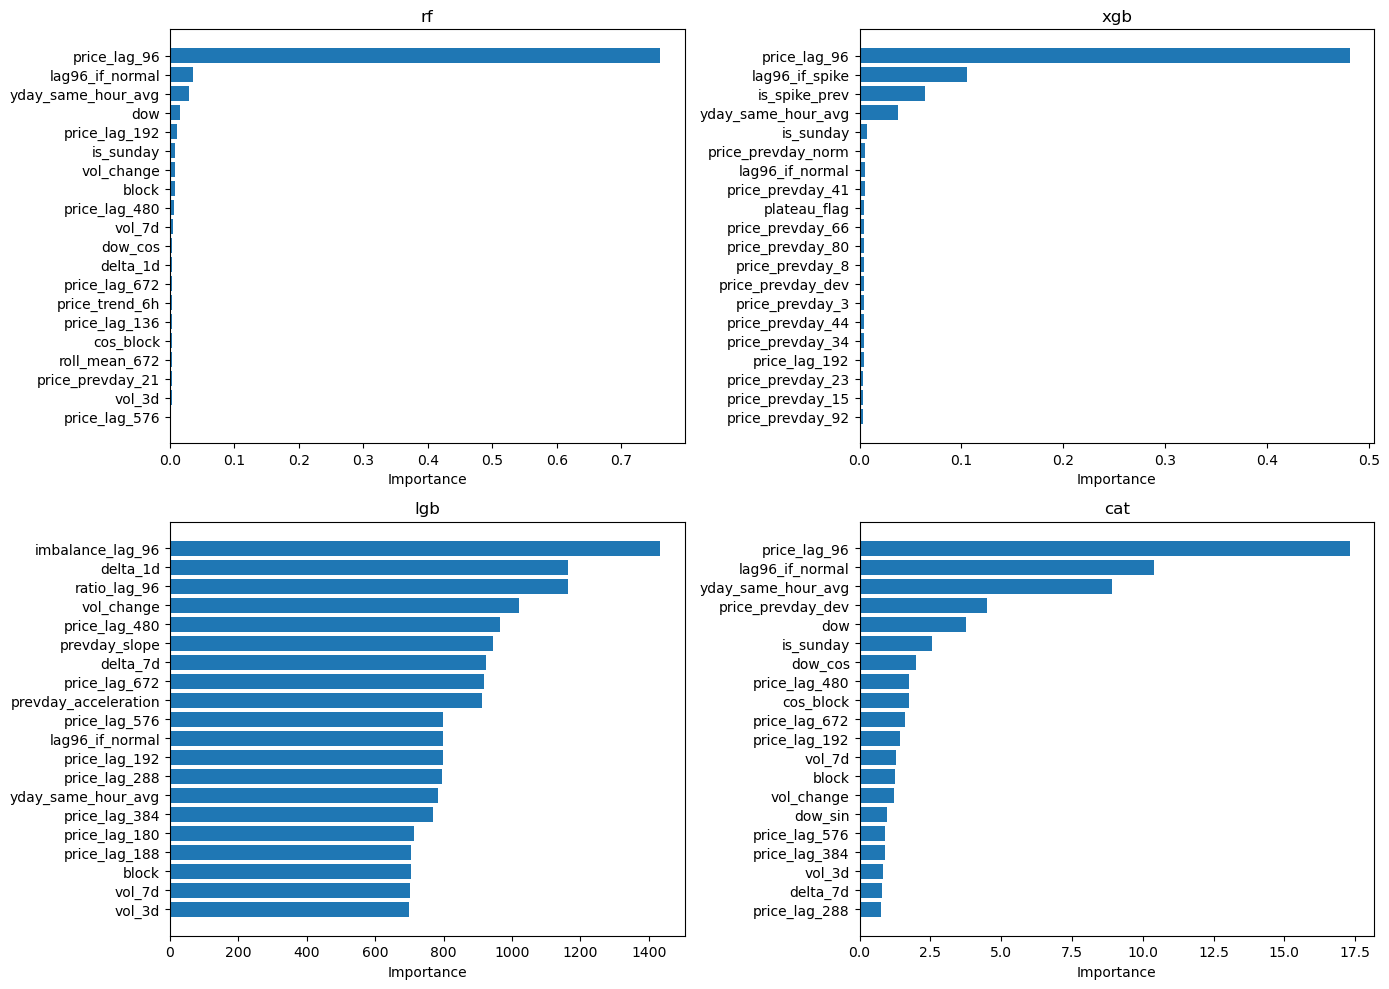

In [52]:
plot_all_feature_importance(model_dict_val, feature_cols, top_n=20)

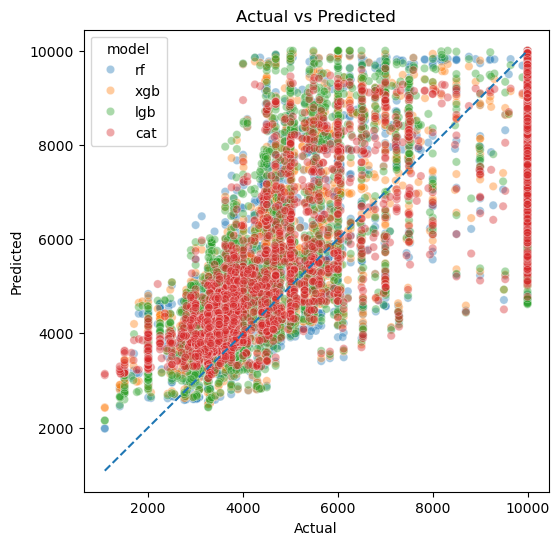

In [53]:
plot_actual_vs_pred_scatter(df_plot_val)

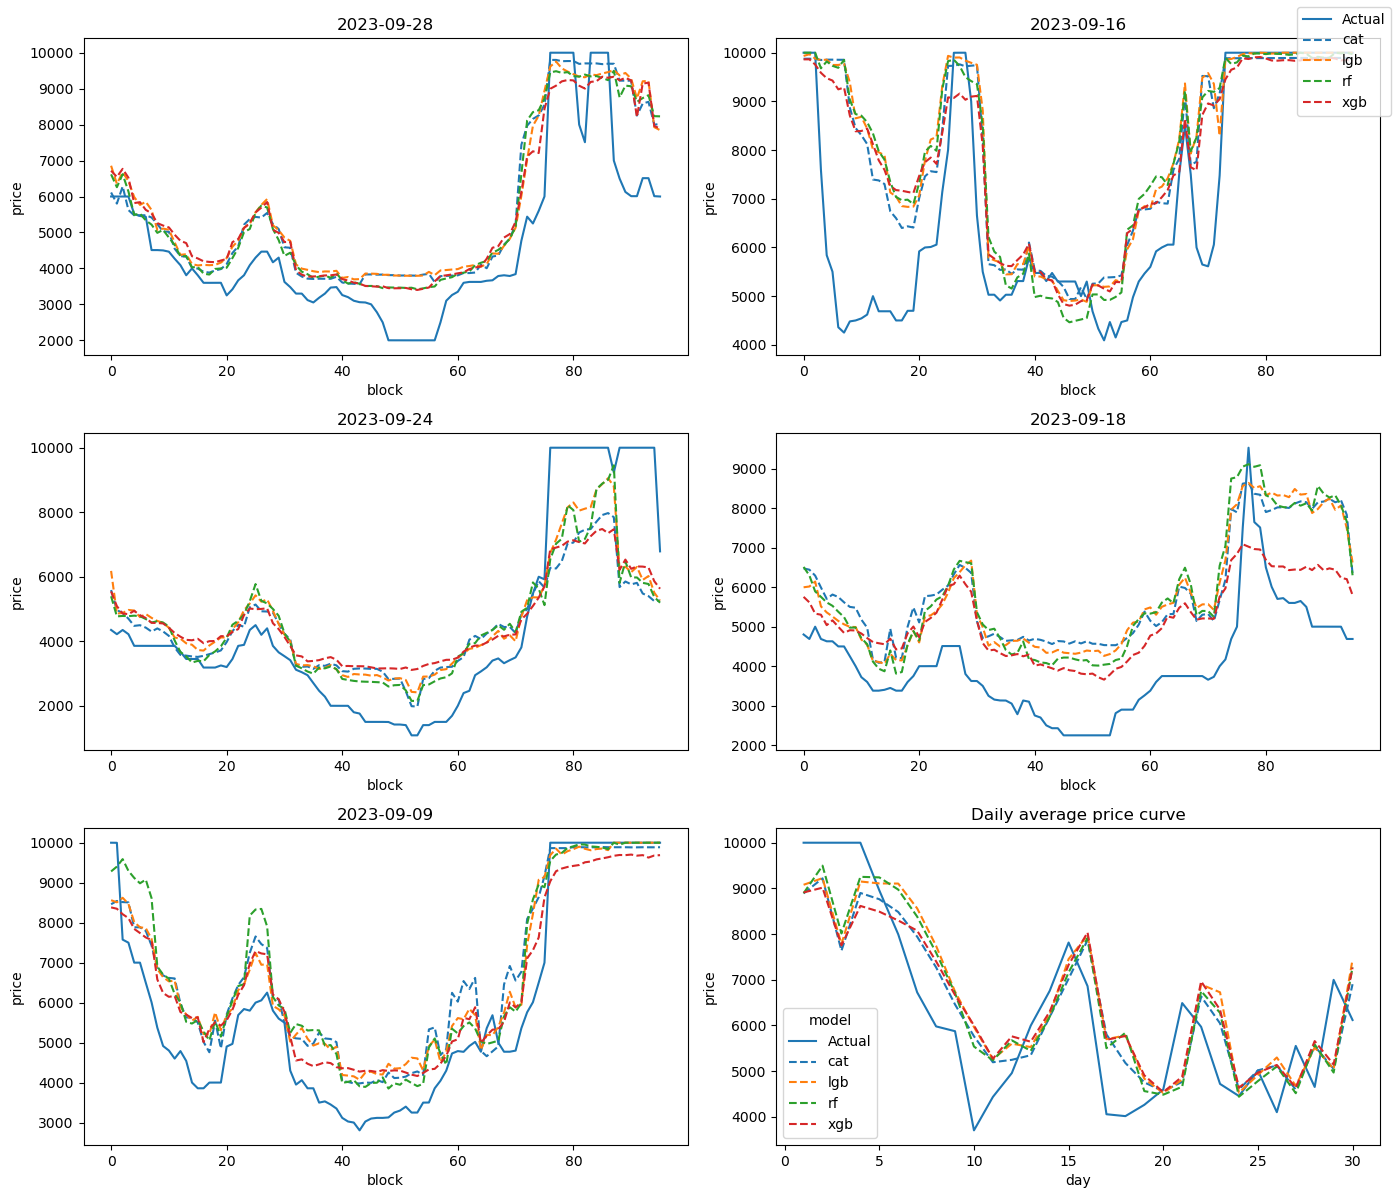

In [54]:
plot_daily_curves(df_plot_val, n_days=5, seed=42)

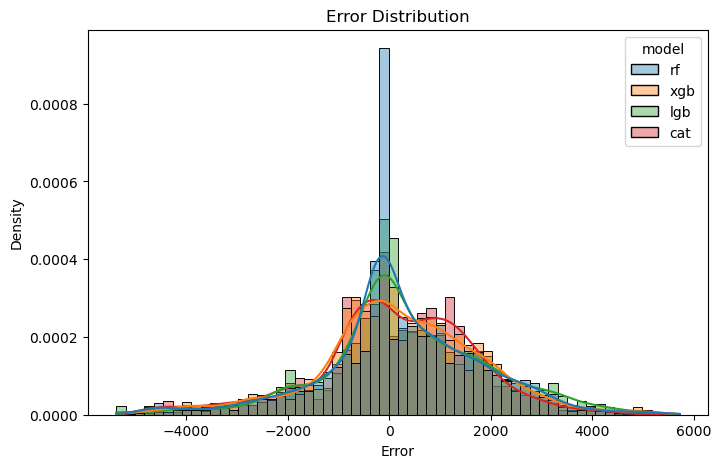

In [55]:
plot_error_distribution(df_plot_val)

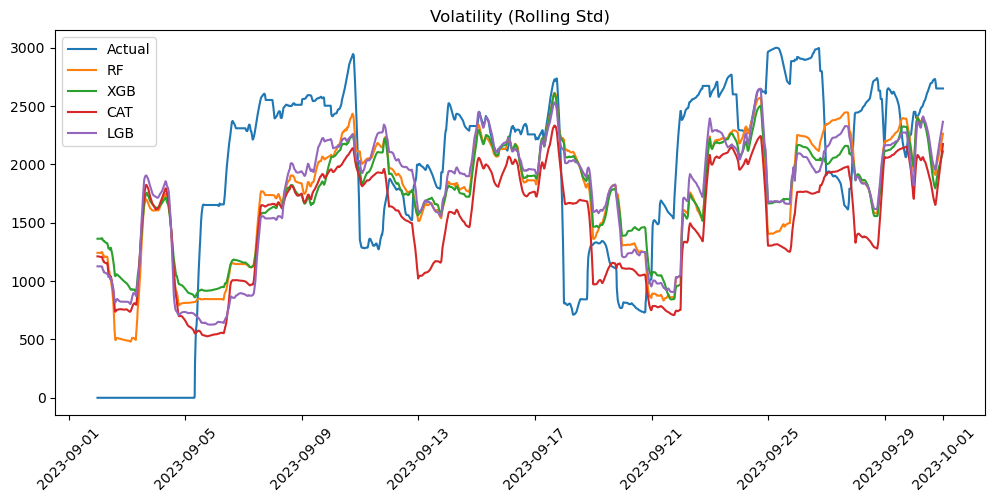

In [56]:
plot_volatility(df_plot_val)

#### Test dataset

In [57]:
results_test = []
model_dict_test = {}
for m in MODELS:
    print(f'======{m}======')
    df = train_predict(train_val_df, test_df, feature_cols, target_col, model_dict_test, best_params, m)
    results_test.append(df)
results_test = pd.concat(results_test, ignore_index=True)

======rf======
Training done
Prediction done
======xgb======
Training done
Prediction done
======lgb======
Training done
Prediction done
======cat======
Training done
Prediction done


##### Test Evaluation

In [58]:
# evaluation
metrics_test = results_test.groupby('model').apply(
                lambda x: evaluate(x['price'].values, x['y_pred'].values)
            )
metrics_test = metrics_test.apply(pd.Series).reset_index().rename(columns={'index': 'model'})
metrics_test

,model,MAE,RMSE,MAPE
0,cat,978.197687,1419.217966,17.334872
1,lgb,940.879733,1407.430914,16.262771
2,rf,902.086632,1395.881858,16.084174
3,xgb,945.582873,1422.680018,16.462714


##### Test Visualization

In [59]:
## visualization
df_plot_test = results_test.copy()

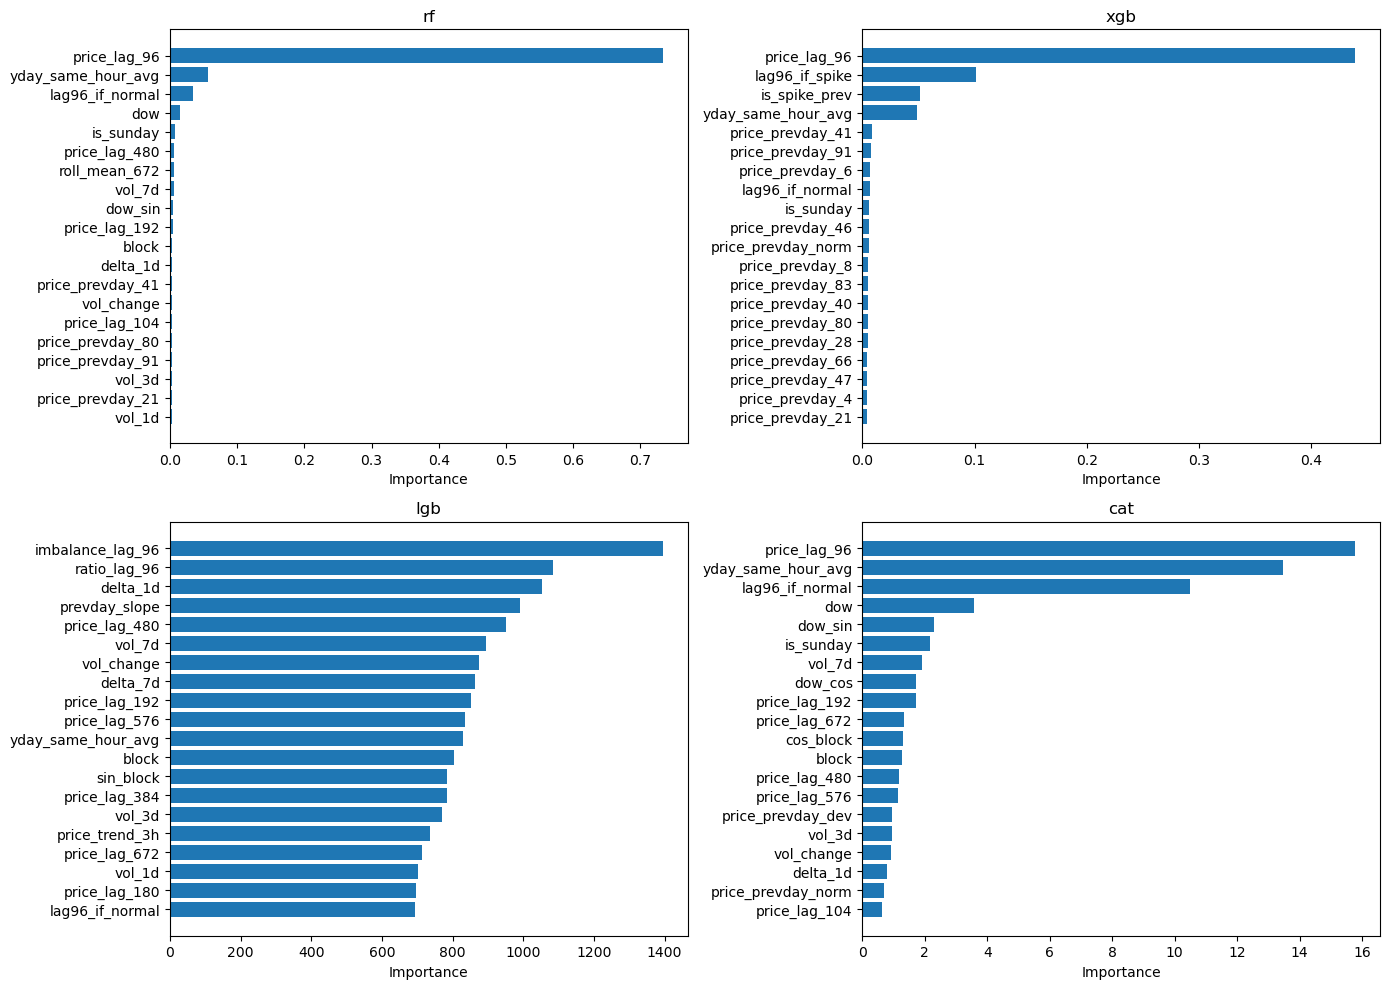

In [60]:
plot_all_feature_importance(model_dict_test, feature_cols, top_n=20)

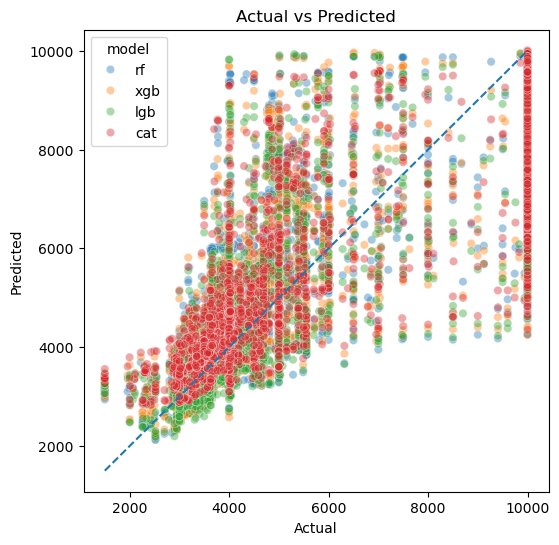

In [61]:
plot_actual_vs_pred_scatter(df_plot_test)

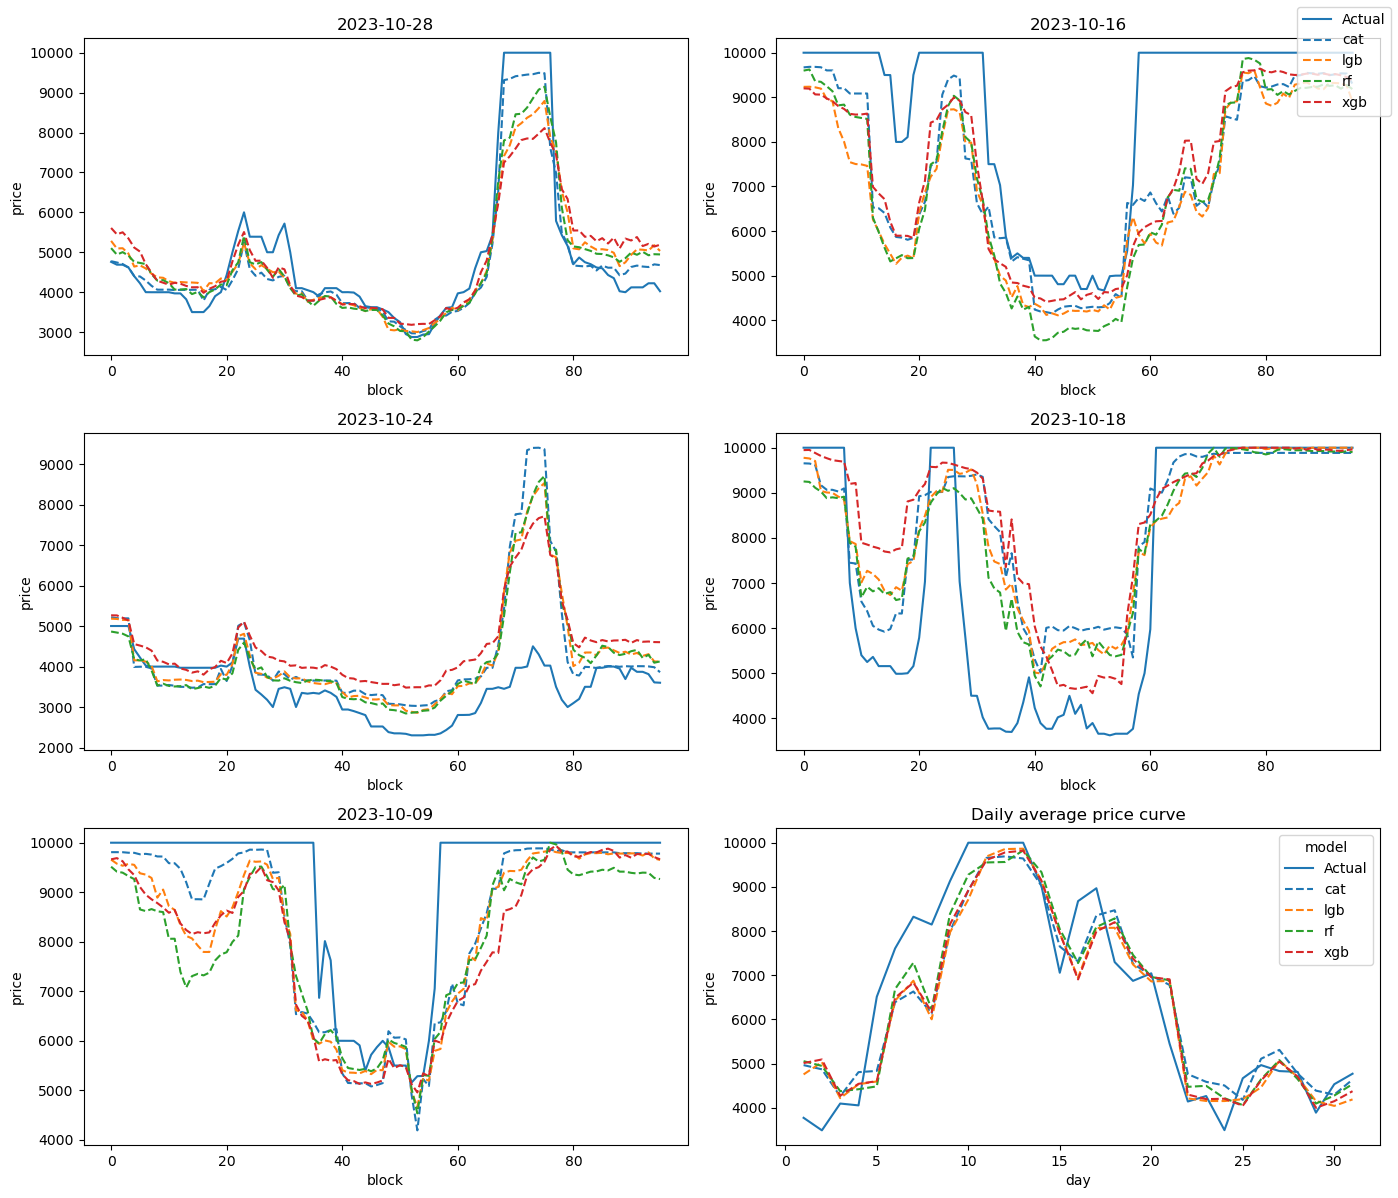

In [62]:
plot_daily_curves(df_plot_test, n_days=5, seed=42)

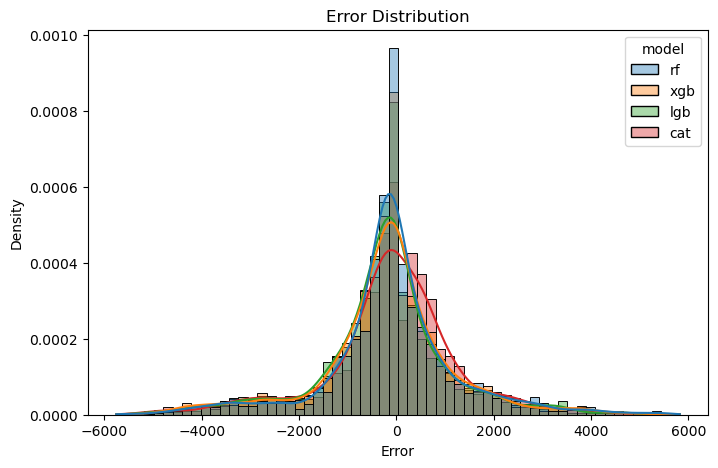

In [63]:
plot_error_distribution(df_plot_test)

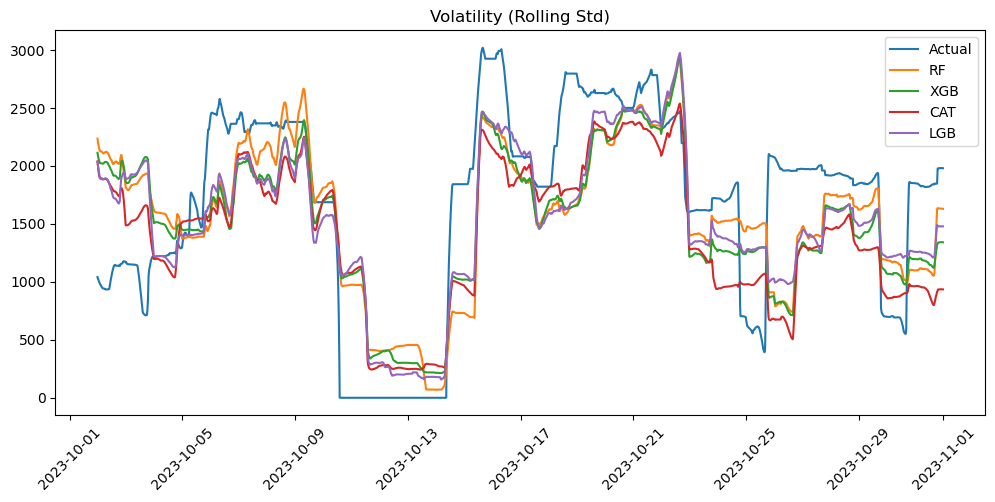

In [64]:
plot_volatility(df_plot_test)

##### Naive test plot and eval

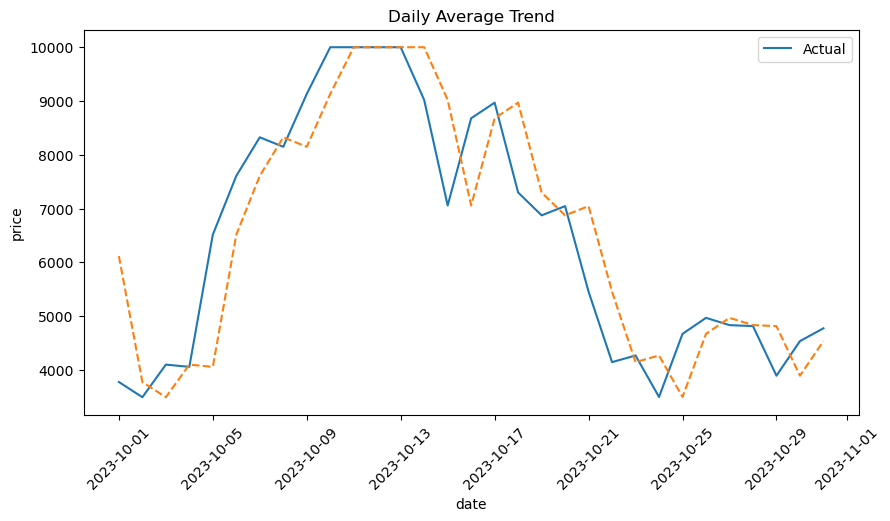

In [65]:
plot_daily_average(test_df)

In [66]:
evaluate(test_df['price'].values, test_df['price_lag_96'].values, "naive_test")


{'MAE': 875.7557325268816,
 'RMSE': np.float64(1685.4309232183498),
 'MAPE': np.float64(16.93931166840521)}

### Ensemble

In [67]:
# Hardcoded
## catboost reduced rmse signigicantly compared to naive, 
    # rf better than others in terms metrics but not as good as naive 
    # on validation dataset
### So we can take ensemble of three: 0.5*y_naive+0.3*rf+0.1*cat+0.1*lgb

In [68]:
ensm = results_test.copy()

In [69]:
results_naive = test_df[['datetime','price', 'price_lag_96']].copy()
results_naive = results_naive.rename(columns={'price_lag_96':'y_pred'})
results_naive['model'] = 'naive'

In [70]:
ensm = pd.concat([ensm, results_naive], ignore_index=True)
ensm = ensm.pivot(index=['datetime', 'price'], columns='model', values='y_pred').reset_index()

In [71]:
ensm.columns.name = None  # remove column index name
ensm = ensm.rename(columns=lambda x: f'y_pred_{x}' if x not in ['datetime', 'price'] else x)

In [72]:
ensm['Predicted Price'] = ensm['y_pred_naive']*0.5+ensm['y_pred_rf']*0.3+ensm['y_pred_cat']*0.1+ensm['y_pred_lgb']*0.1

In [73]:
evaluate(ensm['price'].values, ensm['Predicted Price'])

{'MAE': 870.1960323996091,
 'RMSE': np.float64(1454.319318279536),
 'MAPE': np.float64(15.970921238044117)}

##### Rename the columns and save the predictions

In [74]:
ensm['Delivery Date'] = ensm['datetime'].dt.strftime('%d/%m/%Y')
start = ensm['datetime'].dt.strftime('%H:%M')
end = (ensm['datetime'] + pd.Timedelta(minutes=15)).dt.strftime('%H:%M')
ensm['Time Period'] = start + '-' + end


In [75]:
ensm[['Delivery Date', 'Time Period', 'Predicted Price']]

,Delivery Date,Time Period,Predicted Price
0,01/10/2023,00:00-00:15,9042.825835
1,01/10/2023,00:15-00:30,8833.077026
2,01/10/2023,00:30-00:45,8853.189038
3,01/10/2023,00:45-01:00,8819.746893
4,01/10/2023,01:00-01:15,8795.426318
...,...,...,...
2971,31/10/2023,22:45-23:00,4127.648102
2972,31/10/2023,23:00-23:15,4114.712041
2973,31/10/2023,23:15-23:30,4117.958209
2974,31/10/2023,23:30-23:45,4118.414152
